NIM Mahasiswa: 24146030
Total Citra Berhasil Dimuat: 1531
Jumlah Data Latih (80%): 1224
Jumlah Data Uji (20%): 307
Sedang melatih model MLP...
Pelatihan Selesai!
=== Classification Report ===
              precision    recall  f1-score   support

       daisy     0.6204    0.5276    0.5702       127
   dandelion     0.6985    0.7722    0.7335       180

    accuracy                         0.6710       307
   macro avg     0.6594    0.6499    0.6519       307
weighted avg     0.6662    0.6710    0.6660       307



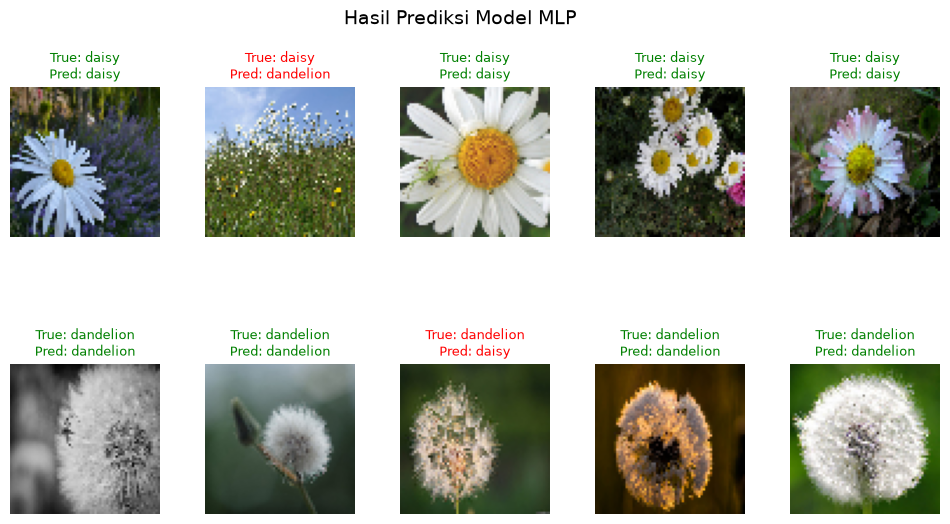

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

# Mengatur NIM sebagai random_state
NIM = 24146030
print(f"NIM Mahasiswa: {NIM}")

DATASET_DIR = "flowers"
CLASSES = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
IMG_SIZE = 64

X = []
y = []
raw_images = []

for label_idx, class_name in enumerate(CLASSES):
    class_dir = os.path.join(DATASET_DIR, class_name)
    if not os.path.exists(class_dir):
        continue
    
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        # Ubah BGR ke RGB & Resize ke 64x64
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
        
        # Normalisasi ke [0, 1] dan Flatten ke 1D Array
        feature_vector = (img_resized / 255.0).flatten()
        
        X.append(feature_vector)
        y.append(label_idx)
        raw_images.append(img_resized)

X = np.array(X)
y = np.array(y)
raw_images = np.array(raw_images)

print(f"Total Citra Berhasil Dimuat: {len(X)}")

# Bagi data 80% Training dan 20% Testing menggunakan NIM sebagai random_state
X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
    X, y, raw_images, test_size=0.2, random_state=NIM, stratify=y
)

print(f"Jumlah Data Latih (80%): {len(X_train)}")
print(f"Jumlah Data Uji (20%): {len(X_test)}")

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=NIM
)

print("Sedang melatih model MLP...")
mlp.fit(X_train, y_train)
print("Pelatihan Selesai!")

y_pred = mlp.predict(X_test)

print("=== Classification Report ===")
# Mengambil nama kelas yang benar-benar ada di dataset
present_classes = [CLASSES[i] for i in np.unique(np.concatenate((y_test, y_pred)))]

print(classification_report(y_test, y_pred, target_names=present_classes, digits=4))

# Ambil kelas yang benar-benar ada di data uji
unique_classes = np.unique(y_test)
num_classes = len(unique_classes)

fig, axes = plt.subplots(num_classes, 5, figsize=(12, 3 * num_classes))
if num_classes == 1:
    axes = np.expand_dims(axes, axis=0)

plt.subplots_adjust(wspace=0.3, hspace=0.5)

for i, class_idx in enumerate(unique_classes):
    class_name = CLASSES[class_idx]
    indices = np.where(y_test == class_idx)[0]
    
    # Ambil maksimal 5 gambar (atau kurang jika sampel tidak cukup)
    num_samples = min(5, len(indices))
    selected_indices = np.random.choice(indices, num_samples, replace=False)
    
    for j, idx in enumerate(selected_indices):
        ax = axes[i, j]
        ax.imshow(img_test[idx])
        
        actual_label = CLASSES[y_test[idx]]
        pred_label = CLASSES[y_pred[idx]]
        
        color = 'green' if actual_label == pred_label else 'red'
        ax.set_title(f"True: {actual_label}\nPred: {pred_label}", color=color, fontsize=9)
        ax.axis('off')

plt.suptitle("Hasil Prediksi Model MLP", fontsize=14)
plt.show()